<a href="https://colab.research.google.com/github/SOURAV143-BIT/ANALYSING-NAME-TRENDS-/blob/main/ANALYSING_NAME_TRENDS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**ANALYSING THE NAMING TRENDS **

IMPORTING LIBRARIES

In [24]:
import pandas as pd
import zipfile
from io import BytesIO
import matplotlib.pyplot as plt

LOADING THE ZIP FILE USING

In [25]:
zip_path = "names.zip"

data = []

with zipfile.ZipFile(zip_path, 'r') as z:
    for file in z.namelist():

        if file.startswith('yob') and file.endswith('.txt'):
            year = int(file[3:7])

df = pd.read_csv(BytesIO(z.read(file)), names=['Name', 'Gender', 'Births'] )

df['Year'] = year

data.append(df)

names = pd.concat(data, ignore_index=True)

print(names.head())

        Name Gender  Births  Year
0       Mary      F    7065  1880
1       Anna      F    2604  1880
2       Emma      F    2003  1880
3  Elizabeth      F    1939  1880
4     Minnie      F    1746  1880


**VIEWING THE DATASET INFORMATION**

In [27]:
print(names.shape)

(2181032, 4)


In [28]:
print(names.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2181032 entries, 0 to 2181031
Data columns (total 4 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   Name    object
 1   Gender  object
 2   Births  int64 
 3   Year    int64 
dtypes: int64(2), object(2)
memory usage: 66.6+ MB
None


In [29]:
print(names.describe())

             Births          Year
count  2.181032e+06  2.181032e+06
mean   1.721031e+02  1.980320e+03
std    1.454575e+03  3.532018e+01
min    5.000000e+00  1.880000e+03
25%    7.000000e+00  1.957000e+03
50%    1.200000e+01  1.990000e+03
75%    3.200000e+01  2.009000e+03
max    9.969200e+04  2.025000e+03


Number of Male and Female Babies Born in a Particular Year

Example for 2010:

In [30]:
year_data = names[names['Year'] == 2010]

gender_births = year_data.groupby('Gender')['Births'].sum()

print(gender_births)

Gender
F    1777595
M    1918676
Name: Births, dtype: int64


visualizing  the number of male and female babies born in 2010

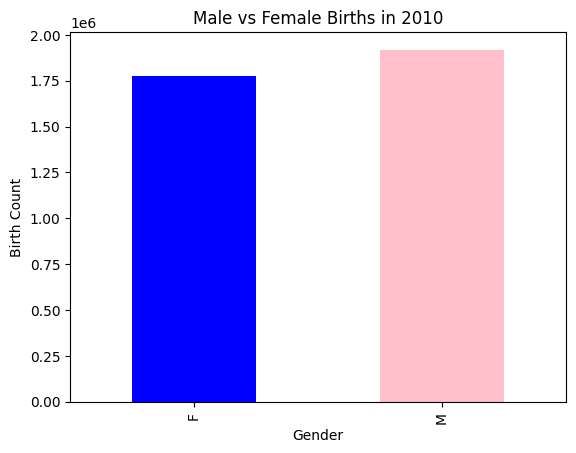

In [31]:
gender_births.plot(kind='bar', color=['blue', 'pink'])
plt.title('Male vs Female Births in 2010')
plt.xlabel('Gender')
plt.ylabel('Birth Count')
plt.show()

FINDING TOP 100 NAMES

In [32]:
top100 = names.groupby('Name')['Births'].sum()
top100 = top100.sort_values(ascending=False).head(100)
print(top100)

Name
James      5274520
John       5204377
Robert     4869849
Michael    4448633
William    4215725
            ...   
Aaron       618857
Brenda      610597
Frances     600721
Jose        596732
Nicole      596465
Name: Births, Length: 100, dtype: int64


VISUALISING  THE TOP 10 NAMES

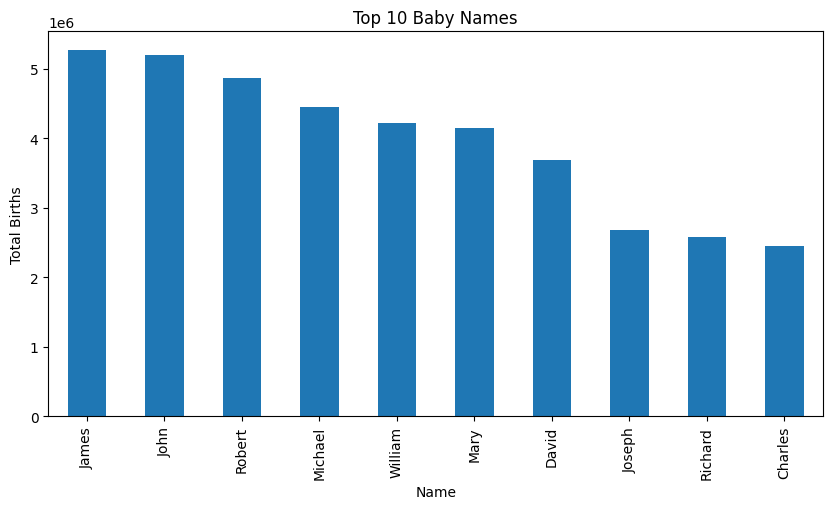

In [33]:
top10 = top100.head(10)

top10.plot(kind='bar',figsize=(10,5))

plt.title('Top 10 Baby Names')
plt.xlabel('Name')
plt.ylabel('Total Births')
plt.show()

MOST POPULAR MALE NAMES

In [34]:
male_names = names[names['Gender'] == 'M']
popular_male = male_names.groupby('Name')['Births'].sum().sort_values(ascending=False).head(10)

print(popular_male)

Name
James      5250638
John       5182633
Robert     4849730
Michael    4426753
William    4199696
David      3676654
Joseph     2669490
Richard    2577552
Charles    2434659
Thomas     2358576
Name: Births, dtype: int64


MOST POPULAR FEMALE NAMES

In [35]:
female_names = names[names['Gender'] == 'F']
popular_female = female_names.groupby('Name')['Births'].sum().sort_values(ascending=False).head(10)

print(popular_female)

Name
Mary         4141481
Elizabeth    1688757
Patricia     1573623
Jennifer     1471703
Linda        1455143
Barbara      1436695
Margaret     1264774
Susan        1123481
Dorothy      1112231
Sarah        1098498
Name: Births, dtype: int64


Trend Analysis for a Specific Name

Example: "Emma"

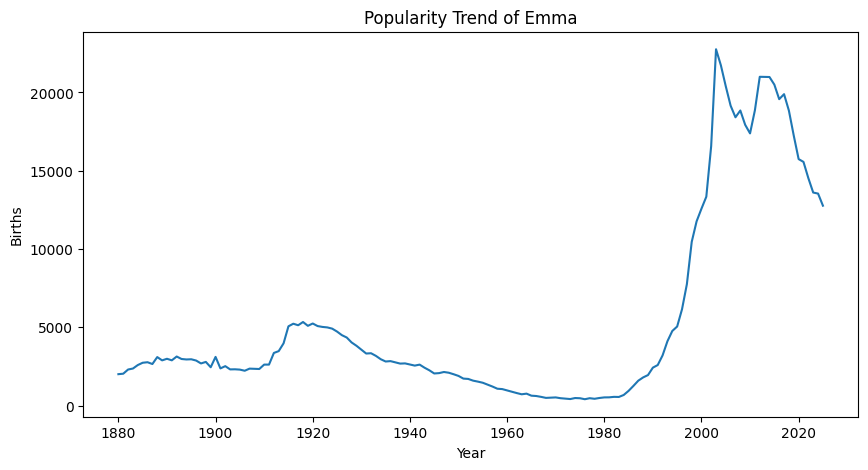

In [36]:
emma = names[names['Name'] == 'Emma']

trend = emma.groupby('Year')['Births'].sum()

trend.plot(figsize=(10,5))

plt.title('Popularity Trend of Emma')
plt.xlabel('Year')
plt.ylabel('Births')
plt.show()